# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [5]:
import pandas as pd

titanic_df = pd.read_csv('titanic_passengers.csv')

titanic_df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
titanic_df['Fare'].mean()

32.204207968574636

In [3]:
titanic_df['Fare'].median()

14.4542

In [4]:
titanic_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

titanic_df = pd.read_csv("titanic_passengers.csv")
titanic_df["Embarked"] = titanic_df["Embarked"].fillna("Unknown")

print(titanic_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


AgeGroup
0-12       0.579710
13-19      0.410526
20-39      0.387597
40-59      0.394161
60+        0.269231
Unknown    0.293785
Name: Survived, dtype: float64


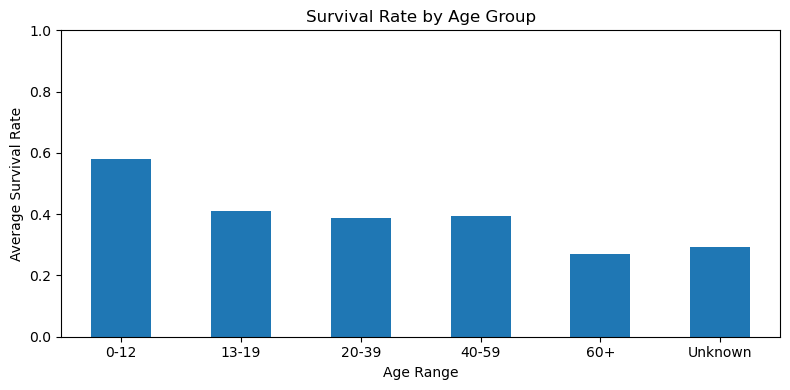

In [17]:
titanic_df["AgeGroup"] = "Unknown"
titanic_df.loc[titanic_df["Age"] < 13, "AgeGroup"] = "0-12"
titanic_df.loc[(titanic_df["Age"] >= 13) & (titanic_df["Age"] < 20), "AgeGroup"] = "13-19"
titanic_df.loc[(titanic_df["Age"] >= 20) & (titanic_df["Age"] < 40), "AgeGroup"] = "20-39"
titanic_df.loc[(titanic_df["Age"] >= 40) & (titanic_df["Age"] < 60), "AgeGroup"] = "40-59"
titanic_df.loc[titanic_df["Age"] >= 60, "AgeGroup"] = "60+"

age_order = ["0-12", "13-19", "20-39", "40-59", "60+", "Unknown"]
age_survival = titanic_df.groupby("AgeGroup")["Survived"].mean().reindex(age_order)
print(age_survival)

plt.figure(figsize=(8,4))
age_survival.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.ylabel("Average Survival Rate")
plt.xlabel("Age Range")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

FareGroup
0-9.99      0.199405
10-29.99    0.425397
30-49.99    0.405063
50+         0.677019
Unknown          NaN
Name: Survived, dtype: float64


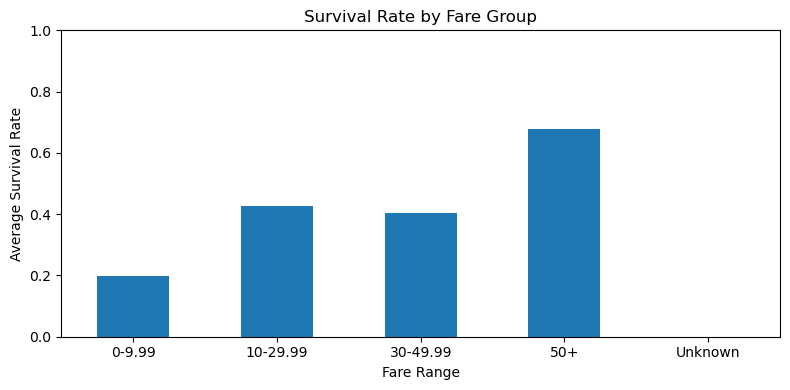

In [16]:
titanic_df["FareGroup"] = "Unknown"
titanic_df.loc[titanic_df["Fare"] < 10, "FareGroup"] = "0-9.99"
titanic_df.loc[(titanic_df["Fare"] >= 10) & (titanic_df["Fare"] < 30), "FareGroup"] = "10-29.99"
titanic_df.loc[(titanic_df["Fare"] >= 30) & (titanic_df["Fare"] < 50), "FareGroup"] = "30-49.99"
titanic_df.loc[titanic_df["Fare"] >= 50, "FareGroup"] = "50+"

fare_order = ["0-9.99", "10-29.99", "30-49.99", "50+", "Unknown"]
fare_survival = titanic_df.groupby("FareGroup")["Survived"].mean().reindex(fare_order)
print(fare_survival)

plt.figure(figsize=(8,4))
fare_survival.plot(kind="bar")
plt.title("Survival Rate by Fare Group")
plt.ylabel("Average Survival Rate")
plt.xlabel("Fare Range")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


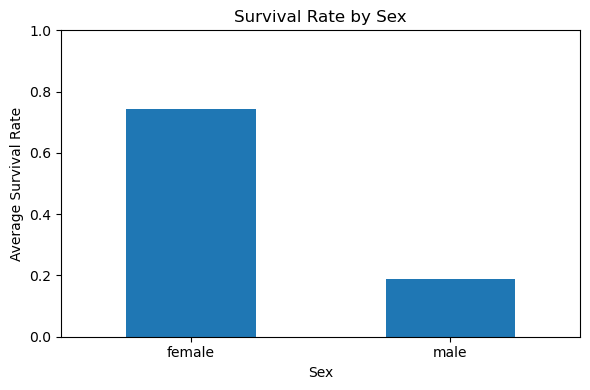

In [4]:
sex_survival = titanic_df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
print(sex_survival)

plt.figure(figsize=(6,4))
sex_survival.plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.ylabel("Average Survival Rate")
plt.xlabel("Sex")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


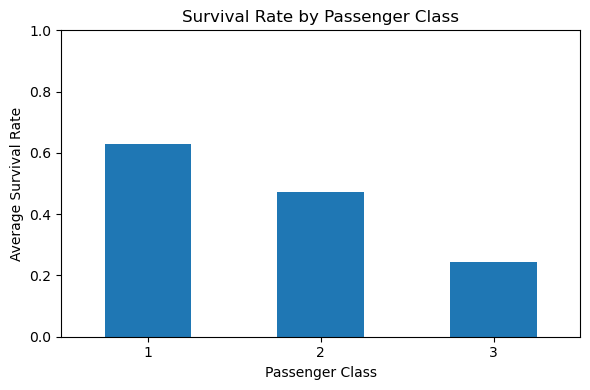

In [5]:
pclass_survival = titanic_df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)
print(pclass_survival)

plt.figure(figsize=(6,4))
pclass_survival.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Average Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

SibSpGroup
1     0.535885
0     0.345395
2+    0.270270
Name: Survived, dtype: float64


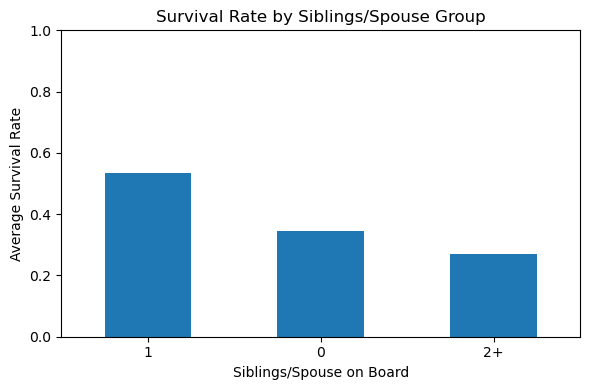

In [6]:
titanic_df["SibSpGroup"] = "0"
titanic_df.loc[titanic_df["SibSp"] == 1, "SibSpGroup"] = "1"
titanic_df.loc[titanic_df["SibSp"] >= 2, "SibSpGroup"] = "2+"

sibsp_survival = titanic_df.groupby("SibSpGroup")["Survived"].mean().sort_values(ascending=False)
print(sibsp_survival)

plt.figure(figsize=(6,4))
sibsp_survival.plot(kind="bar")
plt.title("Survival Rate by Siblings/Spouse Group")
plt.ylabel("Average Survival Rate")
plt.xlabel("Siblings/Spouse on Board")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ParchGroup
1     0.550847
2+    0.463158
0     0.343658
Name: Survived, dtype: float64


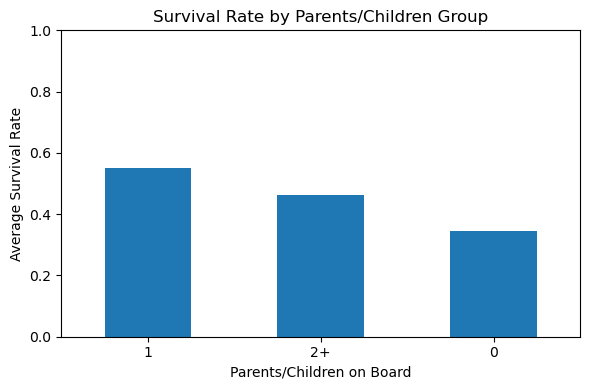

In [7]:
titanic_df["ParchGroup"] = "0"
titanic_df.loc[titanic_df["Parch"] == 1, "ParchGroup"] = "1"
titanic_df.loc[titanic_df["Parch"] >= 2, "ParchGroup"] = "2+"

parch_survival = titanic_df.groupby("ParchGroup")["Survived"].mean().sort_values(ascending=False)
print(parch_survival)

plt.figure(figsize=(6,4))
parch_survival.plot(kind="bar")
plt.title("Survival Rate by Parents/Children Group")
plt.ylabel("Average Survival Rate")
plt.xlabel("Parents/Children on Board")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

EmbarkedName
Unknown        1.000000
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: Survived, dtype: float64


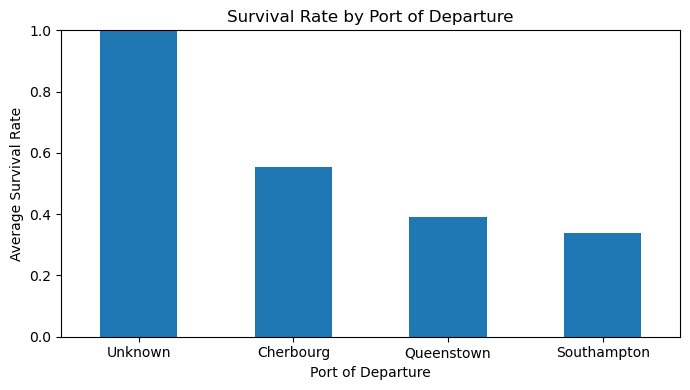

In [8]:
embarked_labels = {
    "S": "Southampton",
    "C": "Cherbourg",
    "Q": "Queenstown",
    "Unknown": "Unknown"
}

titanic_df["EmbarkedName"] = titanic_df["Embarked"].map(embarked_labels).fillna("Unknown")

embarked_survival = titanic_df.groupby("EmbarkedName")["Survived"].mean().sort_values(ascending=False)
print(embarked_survival)

plt.figure(figsize=(7,4))
embarked_survival.plot(kind="bar")
plt.title("Survival Rate by Port of Departure")
plt.ylabel("Average Survival Rate")
plt.xlabel("Port of Departure")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
most_likely_profile = {
    "Sex": sex_survival.idxmax(),
    "Pclass": pclass_survival.idxmax(),
    "AgeGroup": age_survival.idxmax(),
    "FareGroup": fare_survival.idxmax(),
    "SibSpGroup": sibsp_survival.idxmax(),
    "ParchGroup": parch_survival.idxmax(),
    "EmbarkedName": embarked_survival.idxmax()
}

least_likely_profile = {
    "Sex": sex_survival.idxmin(),
    "Pclass": pclass_survival.idxmin(),
    "AgeGroup": age_survival.idxmin(),
    "FareGroup": fare_survival.idxmin(),
    "SibSpGroup": sibsp_survival.idxmin(),
    "ParchGroup": parch_survival.idxmin(),
    "EmbarkedName": embarked_survival.idxmin()
}

# Function to score how closely each passenger matches a profile
def score_profile(df, profile, want_survived=None):
    temp = df.copy()
    
    temp["match_score"] = 0
    temp["match_score"] += (temp["Sex"] == profile["Sex"]).astype(int)
    temp["match_score"] += (temp["Pclass"] == profile["Pclass"]).astype(int)
    temp["match_score"] += (temp["AgeGroup"] == profile["AgeGroup"]).astype(int)
    temp["match_score"] += (temp["FareGroup"] == profile["FareGroup"]).astype(int)
    temp["match_score"] += (temp["SibSpGroup"] == profile["SibSpGroup"]).astype(int)
    temp["match_score"] += (temp["ParchGroup"] == profile["ParchGroup"]).astype(int)
    temp["match_score"] += (temp["EmbarkedName"] == profile["EmbarkedName"]).astype(int)
    
    if want_survived is not None:
        temp = temp[temp["Survived"] == want_survived]
    
    temp = temp.sort_values(by="match_score", ascending=False)
    return temp[[
        "Name", "Survived", "Sex", "Age", "Fare", "Pclass",
        "SibSp", "Parch", "EmbarkedName", "match_score"
    ]]


best_most_match = score_profile(titanic_df, most_likely_profile, want_survived=1)


best_least_match = score_profile(titanic_df, least_likely_profile, want_survived=0)

print("Best passenger matches for MOST likely to survive profile:")
print(best_most_match.head(10))
print()

print("Best passenger matches for LEAST likely to survive profile:")
print(best_least_match.head(10))

Best passenger matches for MOST likely to survive profile:
                                                  Name  Survived     Sex  \
835                        Compton, Miss. Sara Rebecca         1  female   
820  Hays, Mrs. Charles Melville (Clara Jennings Gr...         1  female   
871   Beckwith, Mrs. Richard Leonard (Sallie Monypeny)         1  female   
319  Spedden, Mrs. Frederic Oakley (Margaretta Corn...         1  female   
581  Thayer, Mrs. John Borland (Marian Longstreth M...         1  female   
856         Wick, Mrs. George Dennick (Mary Hitchcock)         1  female   
558             Taussig, Mrs. Emil (Tillie Mandelbaum)         1  female   
457                  Kenyon, Mrs. Frederick R (Marion)         1  female   
215                            Newell, Miss. Madeleine         1  female   
486    Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)         1  female   

      Age      Fare  Pclass  SibSp  Parch EmbarkedName  match_score  
835  39.0   83.1583       1      1

Sara Rebecca Compton fits the profile of the passenger most likely to survive because she was a 39-year-old female in first class who paid a high fare and boarded at Cherbourg. These traits matched several of the categories in the dataset with stronger survival rates. One interesting fact is that she was traveling on the Titanic with her mother and her brother, which connects her data profile to a real family story from the ship.

Johan Hansen Nysveen fits the profile of the passenger least likely to survive because he was a 61-year-old male in third class who paid a very low fare and boarded at Southampton. These traits matched several of the categories in the dataset with lower survival rates. One interesting fact is that he had lived in North Dakota, returned to Norway, remarried, and was traveling back to North Dakota on the Titanic to handle family business, which makes his story especially sad.